## This is the Eda for Bhaisepati data 

### Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


Pandas: 3.0.5
NumPy: 2.5.2


check data path 

In [3]:
DATA_DIR = Path("../data/raw/bhaisepati")
print(DATA_DIR)
print(list(DATA_DIR.iterdir()))

..\data\raw\bhaisepati
[WindowsPath('../data/raw/bhaisepati/pm1.csv'), WindowsPath('../data/raw/bhaisepati/pm10.csv'), WindowsPath('../data/raw/bhaisepati/pm25.csv')]


### get data 

In [4]:
pm10 = pd.read_csv(DATA_DIR / "pm10.csv")
pm1 = pd.read_csv(DATA_DIR / "pm1.csv")
pm25 = pd.read_csv(DATA_DIR / "pm25.csv")

print("PM10 shape :", pm10.shape)
print("PM1 shape  :", pm1.shape)
print("PM2.5 shape:", pm25.shape)

PM10 shape : (23299, 2)
PM1 shape  : (23246, 2)
PM2.5 shape: (23299, 2)


In [5]:
display(pm10.head())
display(pm1.head())
display(pm25.head())

,datetime,pm10
0,2026-07-27 00:01:00+00:00,4.7
1,2026-07-27 00:02:00+00:00,5.4
2,2026-07-27 00:03:00+00:00,5.9
3,2026-07-27 00:04:00+00:00,4.7
4,2026-07-27 00:05:00+00:00,5.3


,datetime,pm1
0,2026-07-27 00:01:00+00:00,4.5
1,2026-07-27 00:02:00+00:00,4.9
2,2026-07-27 00:03:00+00:00,4.6
3,2026-07-27 00:04:00+00:00,4.7
4,2026-07-27 00:05:00+00:00,5.2


,datetime,pm25
0,2026-07-27 00:01:00+00:00,4.7
1,2026-07-27 00:02:00+00:00,5.4
2,2026-07-27 00:03:00+00:00,5.5
3,2026-07-27 00:04:00+00:00,4.7
4,2026-07-27 00:05:00+00:00,5.3


In [6]:
display(pm10.tail())
display(pm1.tail())
display(pm25.tail())

,datetime,pm10
23294,2026-08-12 03:43:00+00:00,14.6
23295,2026-08-12 03:44:00+00:00,13.0
23296,2026-08-12 03:45:00+00:00,13.8
23297,2026-08-12 03:46:00+00:00,13.5
23298,2026-08-12 03:47:00+00:00,14.8


,datetime,pm1
23241,2026-08-12 02:53:00+00:00,10.5
23242,2026-08-12 02:54:00+00:00,10.1
23243,2026-08-12 02:55:00+00:00,8.8
23244,2026-08-12 02:56:00+00:00,10.3
23245,2026-08-12 02:57:00+00:00,8.0


,datetime,pm25
23294,2026-08-12 03:43:00+00:00,11.0
23295,2026-08-12 03:44:00+00:00,9.4
23296,2026-08-12 03:45:00+00:00,10.6
23297,2026-08-12 03:46:00+00:00,10.1
23298,2026-08-12 03:47:00+00:00,9.9


In [9]:
print("PM10")
print(pm10.info())


PM10
<class 'pandas.DataFrame'>
RangeIndex: 23299 entries, 0 to 23298
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  23299 non-null  str    
 1   pm10      23299 non-null  float64
dtypes: float64(1), str(1)
memory usage: 364.2 KB
None


In [12]:

print("\nPM1")
print(pm1.info())




PM1
<class 'pandas.DataFrame'>
RangeIndex: 23246 entries, 0 to 23245
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  23246 non-null  str    
 1   pm1       23246 non-null  float64
dtypes: float64(1), str(1)
memory usage: 363.3 KB
None


In [11]:
print("\nPM2.5")
print(pm25.info())


PM2.5
<class 'pandas.DataFrame'>
RangeIndex: 23299 entries, 0 to 23298
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  23299 non-null  str    
 1   pm25      23299 non-null  float64
dtypes: float64(1), str(1)
memory usage: 364.2 KB
None


### converting datetime

In [13]:
pm10["datetime"] = pd.to_datetime(pm10["datetime"], utc=True)
pm1["datetime"] = pd.to_datetime(pm1["datetime"], utc=True)
pm25["datetime"] = pd.to_datetime(pm25["datetime"], utc=True)

In [14]:
print(pm10.dtypes)

datetime    datetime64[us, UTC]
pm10                    float64
dtype: object


In [15]:
for name, df in {
    "PM10": pm10,
    "PM1": pm1,
    "PM2.5": pm25,
}.items():

    print(f"\n{name}")
    print("Start:", df["datetime"].min())
    print("End:  ", df["datetime"].max())
    print("Rows: ", len(df))


PM10
Start: 2026-07-27 00:01:00+00:00
End:   2026-08-12 03:47:00+00:00
Rows:  23299

PM1
Start: 2026-07-27 00:01:00+00:00
End:   2026-08-12 02:57:00+00:00
Rows:  23246

PM2.5
Start: 2026-07-27 00:01:00+00:00
End:   2026-08-12 03:47:00+00:00
Rows:  23299


## Checking any missing values 

In [16]:
print("Missing values")

print("\nPM10")
print(pm10.isna().sum())

print("\nPM1")
print(pm1.isna().sum())

print("\nPM2.5")
print(pm25.isna().sum())

Missing values

PM10
datetime    0
pm10        0
dtype: int64

PM1
datetime    0
pm1         0
dtype: int64

PM2.5
datetime    0
pm25        0
dtype: int64


Checking invalid values like -9999

In [17]:
print("Invalid -9999 values")

print("PM10 :", (pm10["pm10"] == -9999).sum())
print("PM1  :", (pm1["pm1"] == -9999).sum())
print("PM2.5:", (pm25["pm25"] == -9999).sum())

Invalid -9999 values
PM10 : 0
PM1  : 0
PM2.5: 0


### looking at stats 

In [18]:
print("PM10")
display(pm10["pm10"].describe())

print("PM1")
display(pm1["pm1"].describe())

print("PM2.5")
display(pm25["pm25"].describe())

PM10


count    23299.000000
mean        11.970977
std          8.963314
min          0.800000
25%          7.600000
50%         10.600000
75%         14.400000
max        456.799988
Name: pm10, dtype: float64

PM1


count    23246.000000
mean         7.839753
std          3.828389
min          1.000000
25%          5.100000
50%          7.200000
75%          9.900000
max         52.099998
Name: pm1, dtype: float64

PM2.5


count    23299.000000
mean         9.238178
std          4.954431
min          0.800000
25%          6.100000
50%          8.500000
75%         11.500000
max        283.200012
Name: pm25, dtype: float64

## checking duplicat timestamps

In [19]:
print("Duplicate timestamps")

print("PM10 :", pm10["datetime"].duplicated().sum())
print("PM1  :", pm1["datetime"].duplicated().sum())
print("PM2.5:", pm25["datetime"].duplicated().sum())

Duplicate timestamps
PM10 : 0
PM1  : 0
PM2.5: 0


### Plotting pm2.5

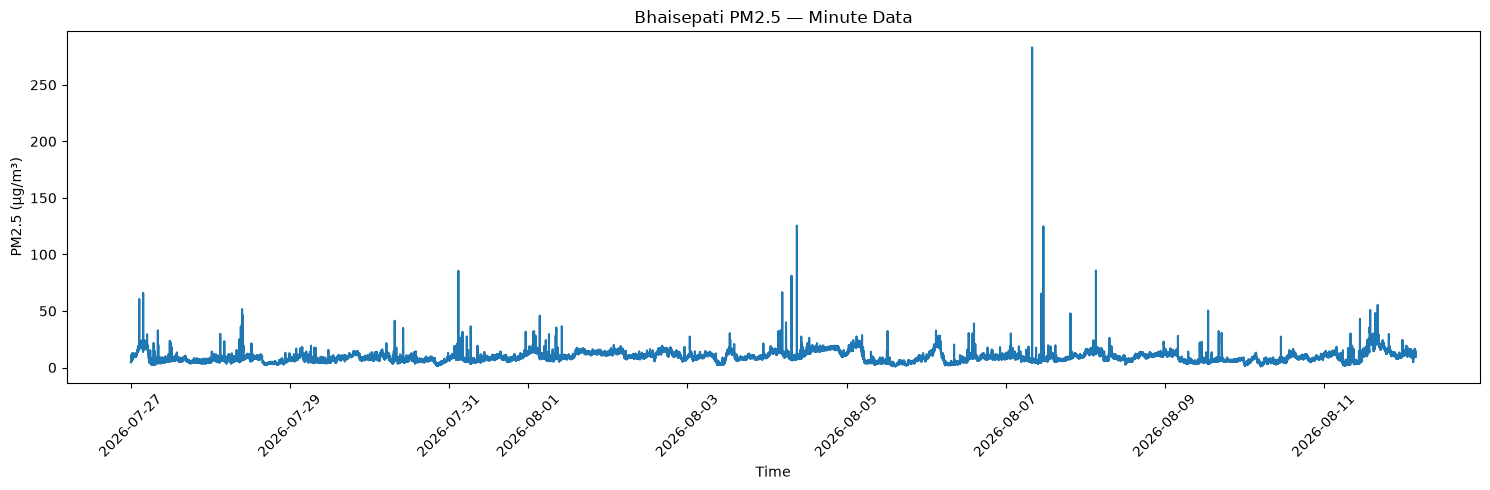

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    pm25["datetime"],
    pm25["pm25"],
)
plt.title("Bhaisepati PM2.5 — Minute Data")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plotting pm10

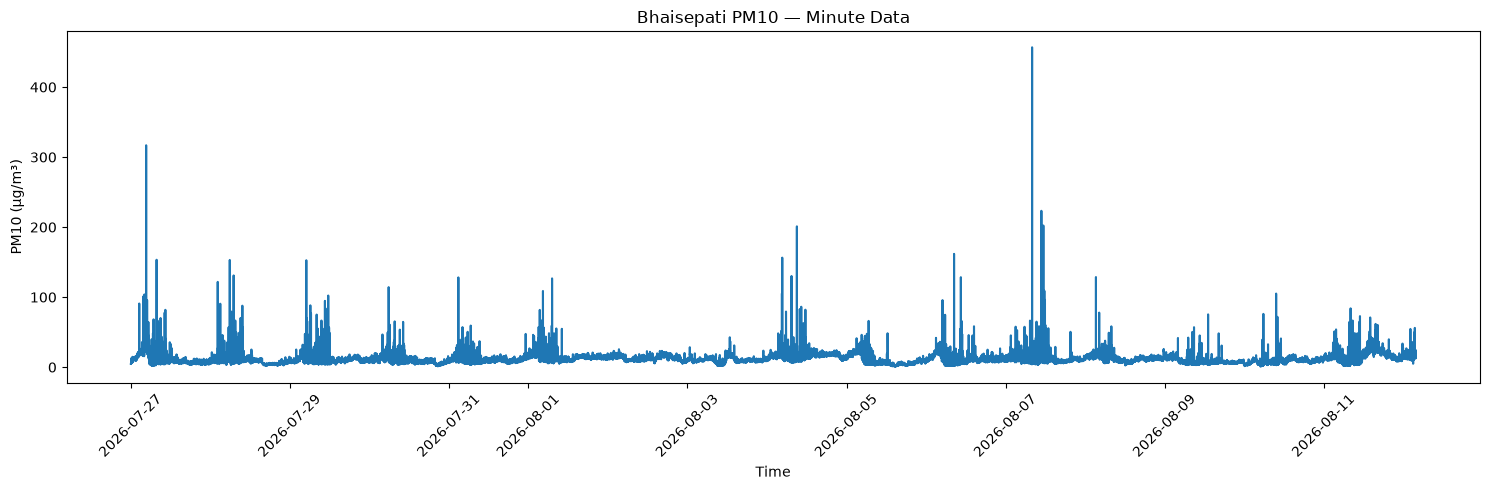

In [23]:
plt.figure(figsize=(15, 5))

plt.plot(
    pm10["datetime"],
    pm10["pm10"],
)
plt.title("Bhaisepati PM10 — Minute Data")
plt.xlabel("Time")
plt.ylabel("PM10 (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

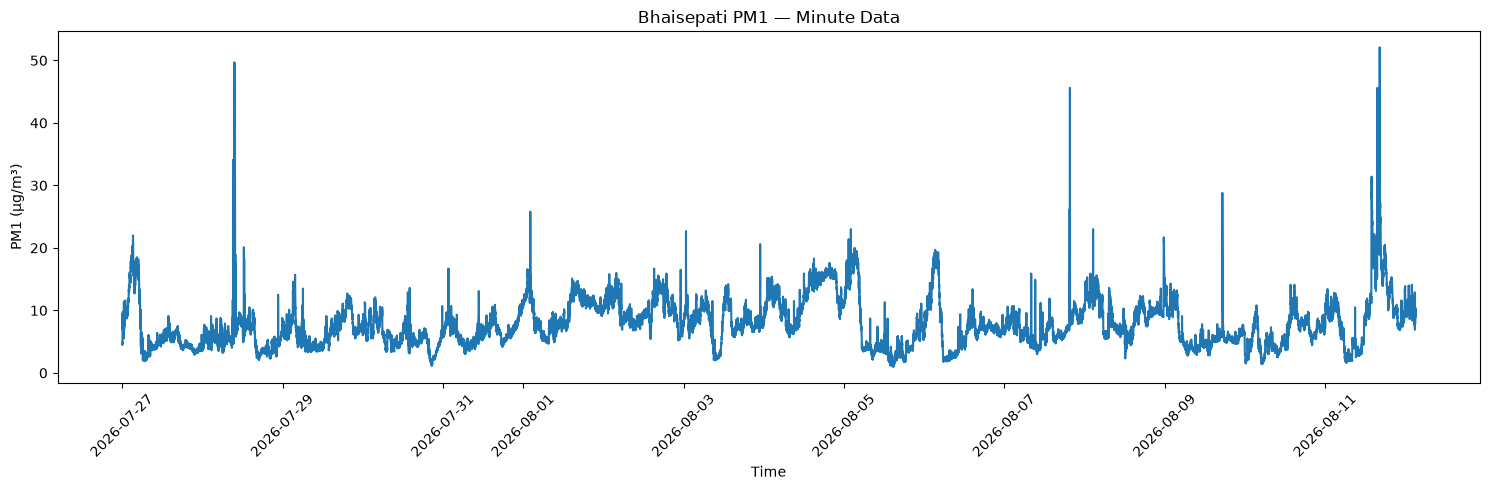

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(
    pm1["datetime"],
    pm1["pm1"],
)

plt.title("Bhaisepati PM1 — Minute Data")
plt.xlabel("Time")
plt.ylabel("PM1 (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Merging data
### We have checked all the necessary missing values and duplicates and invalid ones , where we got none in this data set that is why let start by merging the whole data into one and converting minute data to hourly and work on it 

In [25]:
combined = pd.merge(
    pm10,
    pm1,
    on="datetime",
    how="outer"
)

combined = pd.merge(
    combined,
    pm25,
    on="datetime",
    how="outer"
)

In [26]:
combined

,datetime,pm10,pm1,pm25
0,2026-07-27 00:01:00+00:00,4.7,4.5,4.7
1,2026-07-27 00:02:00+00:00,5.4,4.9,5.4
2,2026-07-27 00:03:00+00:00,5.9,4.6,5.5
3,2026-07-27 00:04:00+00:00,4.7,4.7,4.7
4,2026-07-27 00:05:00+00:00,5.3,5.2,5.3
...,...,...,...,...
23294,2026-08-12 03:43:00+00:00,14.6,NaN,11.0
23295,2026-08-12 03:44:00+00:00,13.0,NaN,9.4
23296,2026-08-12 03:45:00+00:00,13.8,NaN,10.6
23297,2026-08-12 03:46:00+00:00,13.5,NaN,10.1


### We will be now creating hourly data with mean 

In [27]:
hourly = (
    combined
    .set_index("datetime")
    .resample("1h")
    .mean(numeric_only=True)
    .reset_index()
)

In [28]:
print("Minute rows:", len(combined))
print("Hourly rows:", len(hourly))

Minute rows: 23299
Hourly rows: 388


In [29]:
print("\nHourly missing values:")
print(hourly.isna().sum())


Hourly missing values:
datetime    0
pm10        0
pm1         1
pm25        0
dtype: int64


In [30]:
print("\nHourly date range:")
print("Start:", hourly["datetime"].min())
print("End:  ", hourly["datetime"].max())


Hourly date range:
Start: 2026-07-27 00:00:00+00:00
End:   2026-08-12 03:00:00+00:00


### plotting hourly data for every PM one by one

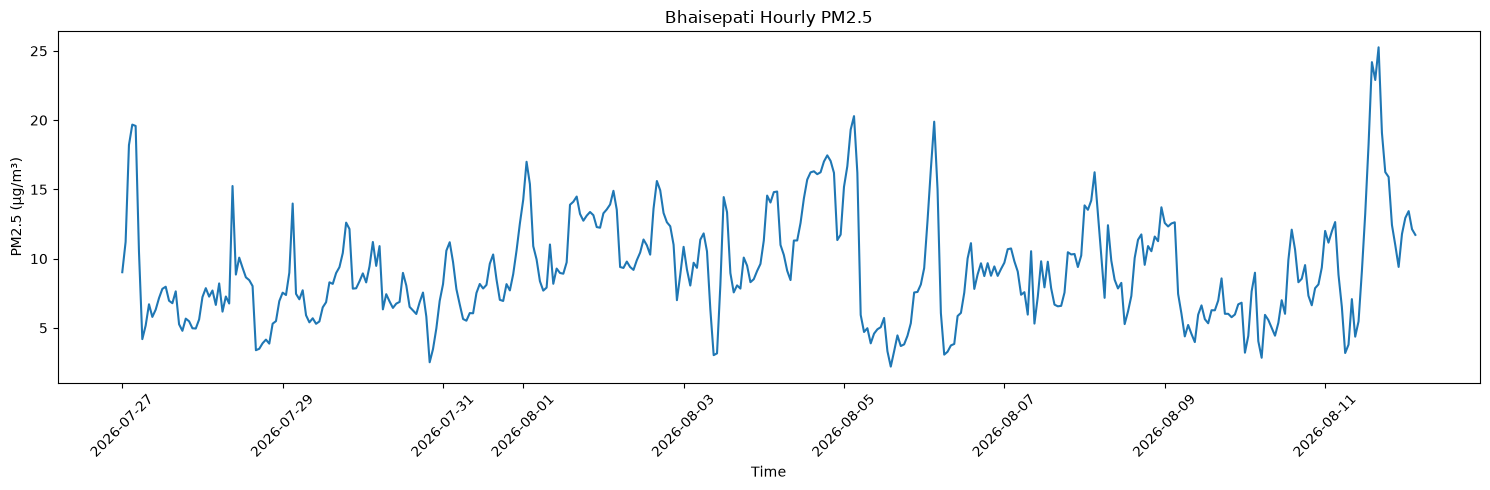

In [31]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly["datetime"],
    hourly["pm25"],
)

plt.title("Bhaisepati Hourly PM2.5")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

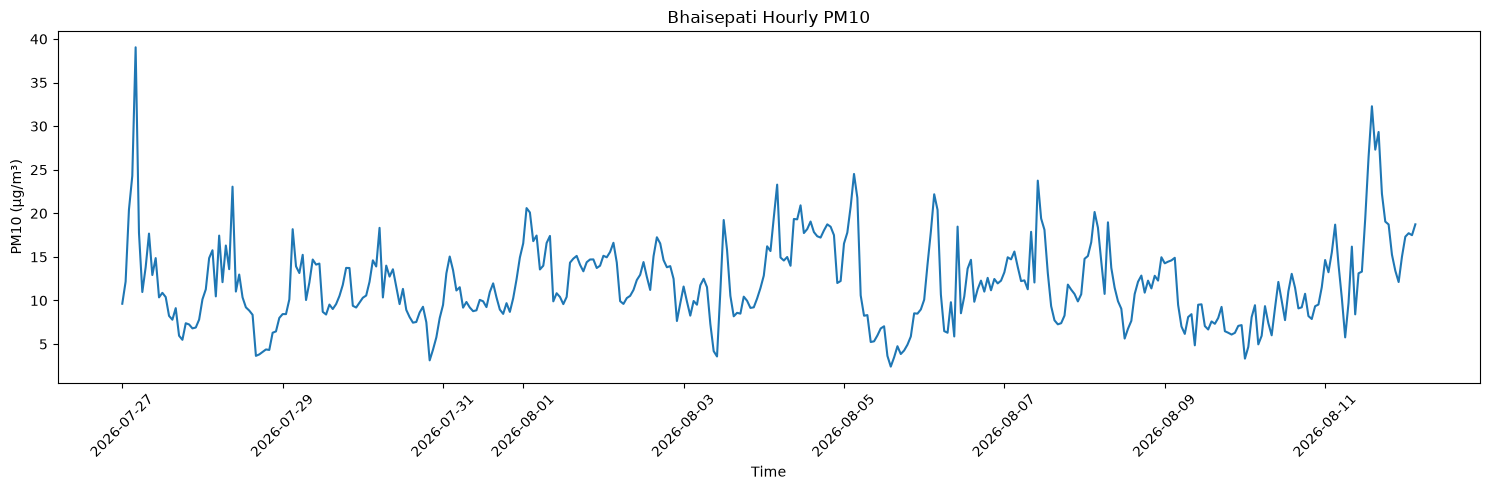

In [33]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly["datetime"],
    hourly["pm10"],
)

plt.title("Bhaisepati Hourly PM10")
plt.xlabel("Time")
plt.ylabel("PM10 (µg/m³)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

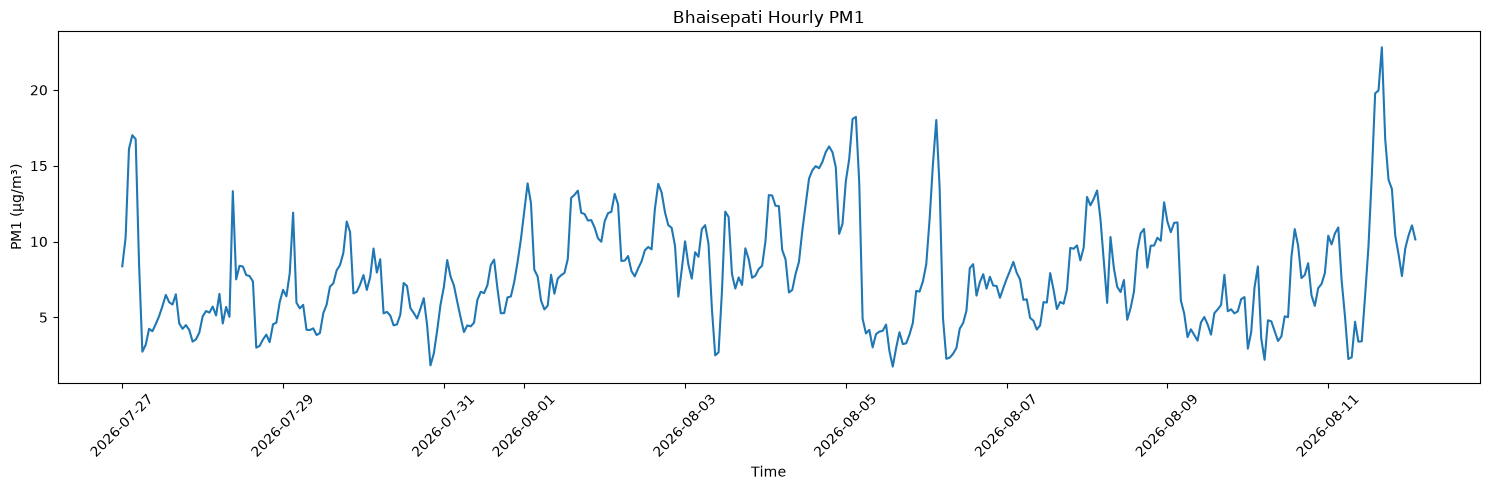

In [34]:
plt.figure(figsize=(15, 5))

plt.plot(
    hourly["datetime"],
    hourly["pm1"],
)

plt.title("Bhaisepati Hourly PM1")
plt.xlabel("Time")
plt.ylabel("PM1 (µg/m³)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### saving processed data 

In [32]:
from pathlib import Path

OUTPUT_DIR = Path("../data/processed/bhaisepati")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_file = OUTPUT_DIR / "hourly.csv"

hourly.to_csv(output_file, index=False)

print(f"Saved to: {output_file}")

Saved to: ..\data\processed\bhaisepati\hourly.csv
